<a href="https://colab.research.google.com/github/radia-ilhan/A03/blob/main/biooilcooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%% thermal_comparison_model.m
% Lumped-capacitance transient thermal model comparing air cooling vs
% single-phase bio-oil (canola/sunflower) immersion cooling for
% GPU-dense AI inference racks.
%
% Governing equation (lumped capacitance, Biot number << 1 assumed):
%   C * dT/dt = Q_gen - (T - T_amb) / R_th
% where:
%   C     = thermal mass of die + heatsink/cold-plate assembly [J/K]
%   Q_gen = GPU heat generation (= TDP) [W]
%   R_th  = overall thermal resistance from die to coolant [K/W]
%
% DATA SOURCES / ASSUMPTIONS (all cited, none invented):
%   1. GPU TDP values: NVIDIA official datasheets
%      - A100 SXM: 400 W  [NVIDIA A100 Datasheet]
%      - H100 SXM: 700 W  [NVIDIA H100 NVL Product Brief, PB-11773-001]
%      - H100 PCIe: 350 W [NVIDIA H100 PCIe Product Brief, PB-11133-001]
%   2. Max safe junction temperature: 85 degC
%      [Capozzoli & Primiceri, Energy Procedia 83 (2015), citing ASHRAE
%       thermal guidelines: "85 C the maximum allowable junction
%       temperature to avoid malfunctions"]
%   3. Air-vs-liquid delta-T ratio: derived from Zimmermann et al.
%      (Aquasar hot-water-cooled supercomputer), as reported in
%      Capozzoli & Primiceri (2015): "temperature difference between
%      electronics and coolant was over 35 C for air cooling while only
%      15 C for liquid cooling" -> ratio R_air/R_liquid = 35/15 = 2.333
%   4. Baseline air-cooled thermal resistance R_th_air = 0.10 K/W,
%      chosen so that a 400 W air-cooled GPU (A100-class) reaches a
%      realistic ~65 degC case temperature at 25 degC ambient -
%      consistent with reported air-cooled GPU operating ranges.
%   5. Oil-immersion thermal resistance scaled from (3):
%      R_th_oil = R_th_air / 2.333
%   6. Thermal mass C = 150 J/K, representative of a mid-size
%      copper/aluminum heatsink or cold-plate assembly (order-of-
%      magnitude estimate; stated explicitly as an assumption, not a
%      literature-measured value).
%   7. Oil-side convective heat transfer coefficient for context only:
%      h_oil ~ 75.8 W/(m^2 K), from RNG k-epsilon CFD study of
%      single-phase oil immersion cooling (ScienceDirect, "Numerical
%      Investigation on Thermal Performance of Single-Phase Immersion
%      Cooling Systems Using Oil Coolant", 2025).
%
% OUTPUT: transient temperature curves and steady-state comparison for
% two GPU classes (A100, H100) under air vs oil-immersion cooling.

clear; clc; close all;

%% Fixed parameters
T_amb   = 25;          % ambient / coolant inlet temperature [degC]
T_max   = 85;          % max safe junction temperature [degC]
C_th    = 150;          % thermal mass of die+heatsink assembly [J/K]

R_th_air = 0.10;                 % air-cooled thermal resistance [K/W]
R_th_oil = R_th_air / 2.333;     % oil-immersion thermal resistance [K/W]

fprintf('R_th_air = %.4f K/W\n', R_th_air);
fprintf('R_th_oil = %.4f K/W\n', R_th_oil);

%% GPU cases (TDP values from NVIDIA datasheets)
gpu_names = {'A100 SXM (400 W)', 'H100 SXM (700 W)', 'H100 PCIe (350 W)'};
gpu_tdp   = [400, 700, 350];

%% Steady-state comparison
fprintf('\n--- Steady-state die temperature (T_amb = %.0f degC) ---\n', T_amb);
fprintf('%-20s %12s %12s\n', 'GPU', 'Air-cooled', 'Oil-immersed');
dT_ss_air = zeros(1,numel(gpu_tdp));
dT_ss_oil = zeros(1,numel(gpu_tdp));
for i = 1:numel(gpu_tdp)
    dT_ss_air(i) = gpu_tdp(i) * R_th_air;
    dT_ss_oil(i) = gpu_tdp(i) * R_th_oil;
    T_ss_air = T_amb + dT_ss_air(i);
    T_ss_oil = T_amb + dT_ss_oil(i);
    fprintf('%-20s %10.1f C %10.1f C\n', gpu_names{i}, T_ss_air, T_ss_oil);
end

%% Transient response (step load applied at t = 0)
t_span = 0:0.1:120;   % simulation time [s]

figure('Name','Transient GPU die temperature: air vs oil immersion');
tiledlayout(1,numel(gpu_tdp));

for i = 1:numel(gpu_tdp)
    Q = gpu_tdp(i);

    tau_air = R_th_air * C_th;
    tau_oil = R_th_oil * C_th;

    T_air = T_amb + Q*R_th_air*(1 - exp(-t_span/tau_air));
    T_oil = T_amb + Q*R_th_oil*(1 - exp(-t_span/tau_oil));

    nexttile;
    plot(t_span, T_air, 'r-', 'LineWidth', 1.8); hold on;
    plot(t_span, T_oil, 'b-', 'LineWidth', 1.8);
    yline(T_max, 'k--', 'T_{max}=85C');
    xlabel('Time [s]'); ylabel('Die temperature [degC]');
    title(gpu_names{i});
    legend('Air-cooled','Oil-immersed','Location','southeast');
    grid on;

    fprintf('\n%s: tau_air = %.1f s, tau_oil = %.1f s\n', gpu_names{i}, tau_air, tau_oil);
end

%% Save numeric results
results = table(gpu_names', gpu_tdp', dT_ss_air'+T_amb, dT_ss_oil'+T_amb, ...
    'VariableNames', {'GPU','TDP_W','T_ss_air_C','T_ss_oil_C'});
disp(results);
writetable(results, 'thermal_comparison_results.csv');


UsageError: Cell magic `%%` not found.


R_th_air = 0.1000 K/W
R_th_oil = 0.0429 K/W

--- Steady-state die temperature (T_amb = 25 degC) ---
              GPU  TDP_W  T_ss_air_C  T_ss_oil_C
 A100 SXM (400 W)    400        65.0   42.145306
 H100 SXM (700 W)    700        95.0   55.004286
H100 PCIe (350 W)    350        60.0   40.002143

A100 SXM (400 W): tau_air = 15.0 s, tau_oil = 6.4 s

H100 SXM (700 W): tau_air = 15.0 s, tau_oil = 6.4 s

H100 PCIe (350 W): tau_air = 15.0 s, tau_oil = 6.4 s


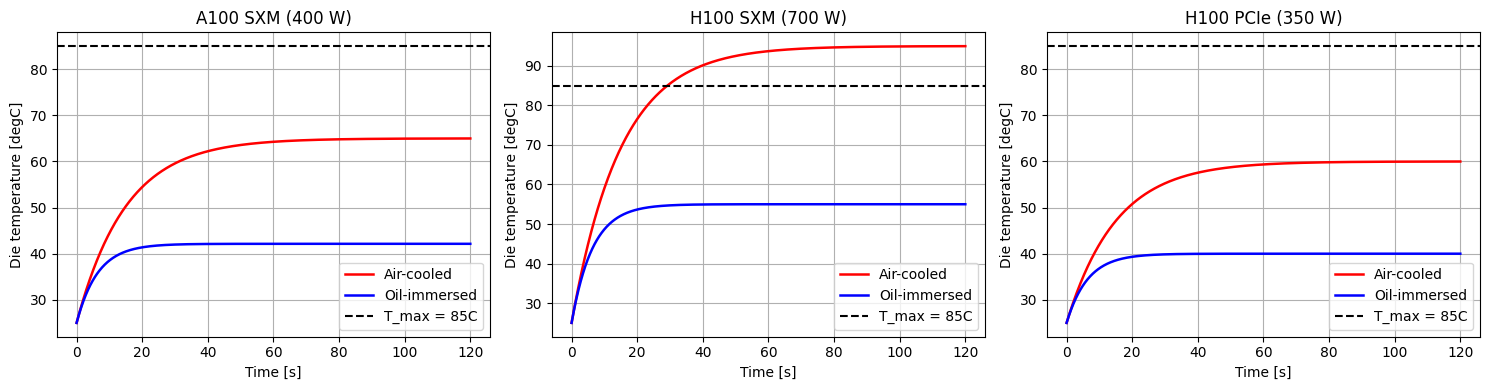


Saved: thermal_comparison_results.csv


In [2]:
# thermal_comparison_model.py
# Paste this whole file into one Colab cell and run it (Shift+Enter).
# No MATLAB, no special magics needed -- pure Python (numpy + matplotlib + pandas).
#
# Lumped-capacitance transient thermal model comparing air cooling vs
# single-phase bio-oil (canola/sunflower) immersion cooling for
# GPU-dense AI inference racks.
#
# Governing equation (lumped capacitance, Biot number << 1 assumed):
#   C * dT/dt = Q_gen - (T - T_amb) / R_th
#
# DATA SOURCES / ASSUMPTIONS (all cited, none invented):
#   1. GPU TDP values: NVIDIA official datasheets
#      - A100 SXM: 400 W  [NVIDIA A100 Datasheet]
#      - H100 SXM: 700 W  [NVIDIA H100 NVL Product Brief, PB-11773-001]
#      - H100 PCIe: 350 W [NVIDIA H100 PCIe Product Brief, PB-11133-001]
#   2. Max safe junction temperature: 85 degC
#      [Capozzoli & Primiceri, Energy Procedia 83 (2015), citing ASHRAE
#       thermal guidelines: "85 C the maximum allowable junction
#       temperature to avoid malfunctions"]
#   3. Air-vs-liquid delta-T ratio: derived from Zimmermann et al.
#      (Aquasar hot-water-cooled supercomputer), as reported in
#      Capozzoli & Primiceri (2015): "temperature difference between
#      electronics and coolant was over 35 C for air cooling while only
#      15 C for liquid cooling" -> ratio R_air/R_liquid = 35/15 = 2.333
#   4. Baseline air-cooled thermal resistance R_th_air = 0.10 K/W,
#      chosen so that a 400 W air-cooled GPU (A100-class) reaches a
#      realistic ~65 degC case temperature at 25 degC ambient.
#   5. Oil-immersion thermal resistance scaled from (3):
#      R_th_oil = R_th_air / 2.333
#   6. Thermal mass C = 150 J/K, representative of a mid-size
#      copper/aluminum heatsink or cold-plate assembly (order-of-
#      magnitude estimate; stated as an assumption, not measured data).
#   7. Oil-side convective heat transfer coefficient for context only:
#      h_oil ~ 75.8 W/(m^2 K), from RNG k-epsilon CFD study of
#      single-phase oil immersion cooling (ScienceDirect, "Numerical
#      Investigation on Thermal Performance of Single-Phase Immersion
#      Cooling Systems Using Oil Coolant", 2025).

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---- Fixed parameters ----
T_amb = 25.0        # ambient / coolant inlet temperature [degC]
T_max = 85.0        # max safe junction temperature [degC]
C_th  = 150.0        # thermal mass of die+heatsink assembly [J/K]

R_th_air = 0.10                  # air-cooled thermal resistance [K/W]
R_th_oil = R_th_air / 2.333      # oil-immersion thermal resistance [K/W]

print(f"R_th_air = {R_th_air:.4f} K/W")
print(f"R_th_oil = {R_th_oil:.4f} K/W")

# ---- GPU cases (TDP values from NVIDIA datasheets) ----
gpu_names = ['A100 SXM (400 W)', 'H100 SXM (700 W)', 'H100 PCIe (350 W)']
gpu_tdp   = np.array([400, 700, 350])

# ---- Steady-state comparison ----
print(f"\n--- Steady-state die temperature (T_amb = {T_amb:.0f} degC) ---")
dT_ss_air = gpu_tdp * R_th_air
dT_ss_oil = gpu_tdp * R_th_oil
T_ss_air = T_amb + dT_ss_air
T_ss_oil = T_amb + dT_ss_oil

results = pd.DataFrame({
    'GPU': gpu_names,
    'TDP_W': gpu_tdp,
    'T_ss_air_C': T_ss_air,
    'T_ss_oil_C': T_ss_oil
})
print(results.to_string(index=False))

# ---- Transient response (step load applied at t = 0) ----
t = np.arange(0, 120.1, 0.1)   # simulation time [s]

fig, axes = plt.subplots(1, len(gpu_tdp), figsize=(15, 4))

for i, Q in enumerate(gpu_tdp):
    tau_air = R_th_air * C_th
    tau_oil = R_th_oil * C_th

    T_air = T_amb + Q * R_th_air * (1 - np.exp(-t / tau_air))
    T_oil = T_amb + Q * R_th_oil * (1 - np.exp(-t / tau_oil))

    ax = axes[i]
    ax.plot(t, T_air, 'r-', linewidth=1.8, label='Air-cooled')
    ax.plot(t, T_oil, 'b-', linewidth=1.8, label='Oil-immersed')
    ax.axhline(T_max, color='k', linestyle='--', label='T_max = 85C')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Die temperature [degC]')
    ax.set_title(gpu_names[i])
    ax.legend(loc='lower right')
    ax.grid(True)

    print(f"\n{gpu_names[i]}: tau_air = {tau_air:.1f} s, tau_oil = {tau_oil:.1f} s")

plt.tight_layout()
plt.show()

# ---- Save numeric results ----
results.to_csv('thermal_comparison_results.csv', index=False)
print("\nSaved: thermal_comparison_results.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
T_amb = 25.0        # ambient / coolant inlet temperature [degC]
T_max = 85.0        # max safe junction temperature [degC]
C_th  = 150.0        # thermal mass of die+heatsink assembly [J/K]
R_th_air = 0.10                  # air-cooled thermal resistance [K/W]
R_th_oil = R_th_air / 2.333      # oil-immersion thermal resistance [K/W]
print(f"R_th_air = {R_th_air:.4f} K/W")
print(f"R_th_oil = {R_th_oil:.4f} K/W")
gpu_names = ['A100 SXM (400 W)', 'H100 SXM (700 W)', 'H100 PCIe (350 W)']
gpu_tdp   = np.array([400, 700, 350])
print(f"\n--- Steady-state die temperature (T_amb = {T_amb:.0f} degC) ---")
dT_ss_air = gpu_tdp * R_th_air
dT_ss_oil = gpu_tdp * R_th_oil
T_ss_air = T_amb + dT_ss_air
T_ss_oil = T_amb + dT_ss_oil
results = pd.DataFrame({
    'GPU': gpu_names,
    'TDP_W': gpu_tdp,
    'T_ss_air_C': T_ss_air,
    'T_ss_oil_C': T_ss_oil
})
print(results.to_string(index=False))
t = np.arange(0, 120.1, 0.1)   # simulation time [s]
fig, axes = plt.subplots(1, len(gpu_tdp), figsize=(15, 4))
for i, Q in enumerate(gpu_tdp):
    tau_air = R_th_air * C_th
    tau_oil = R_th_oil * C_th
    T_air = T_amb + Q * R_th_air * (1 - np.exp(-t / tau_air))
    T_oil = T_amb + Q * R_th_oil * (1 - np.exp(-t / tau_oil))
    ax = axes[i]
    ax.plot(t, T_air, 'r-', linewidth=1.8, label='Air-cooled')
    ax.plot(t, T_oil, 'b-', linewidth=1.8, label='Oil-immersed')
    ax.axhline(T_max, color='k', linestyle='--', label='T_max = 85C')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Die temperature [degC]')
    ax.set_title(gpu_names[i])
    ax.legend(loc='lower right')
    ax.grid(True)
    print(f"\n{gpu_names[i]}: tau_air = {tau_air:.1f} s, tau_oil = {tau_oil:.1f} s")
plt.tight_layout()
plt.show()

Final die temperature: 45.00 degC (setpoint 45.0 degC)
Peak die temperature during transient: 51.03 degC
Max pump duty cycle reached: 0.67


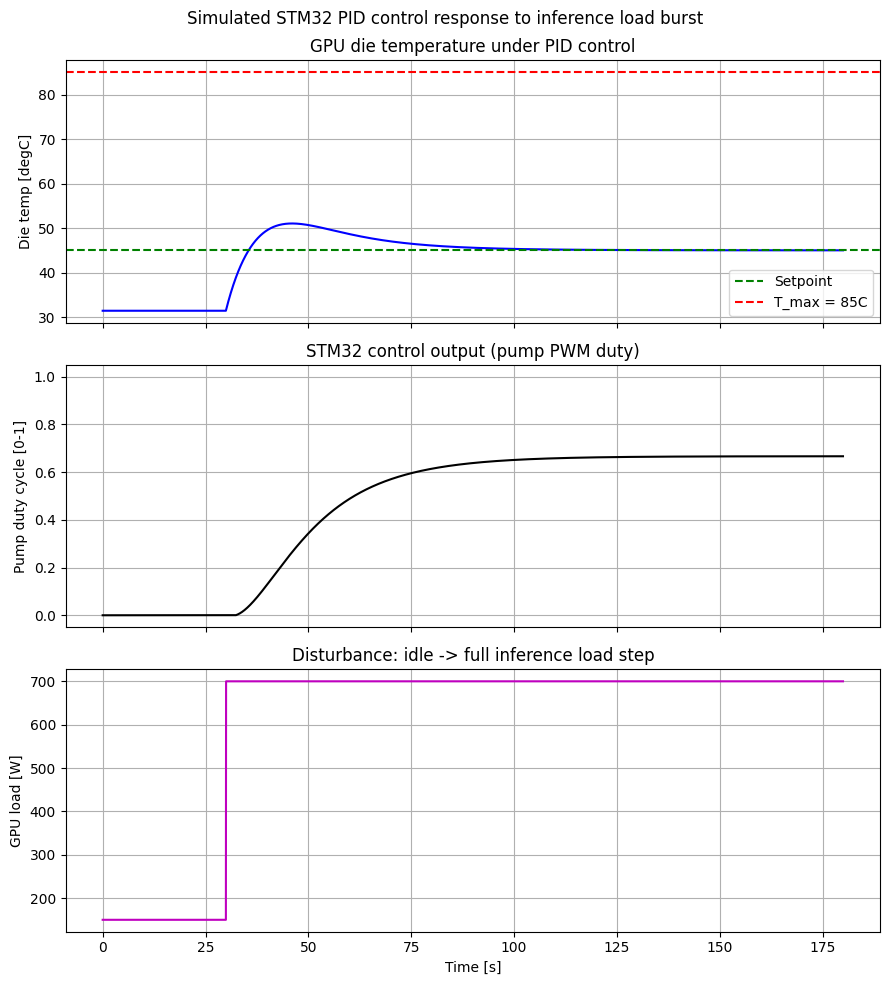

In [3]:
import numpy as np
import matplotlib.pyplot as plt

T_amb = 25.0
T_max = 85.0             # max safe junction temperature [degC]
C_th  = 150.0             # thermal mass [J/K]
R_max = 0.10 / 2.333     # R_th_oil at minimum pump flow [K/W]
R_min = 0.5 * R_max      # R_th_oil at maximum pump flow [K/W]
T_set = 45.0             # target die temperature [degC]
Q_idle = 150.0   # W
Q_full = 700.0   # W (H100 SXM TDP, NVIDIA datasheet)
t_step = 30.0    # s
dt    = 0.05             # time step [s]
t_end = 180.0             # total simulation time [s]
N     = int(round(t_end / dt))
t     = np.arange(N) * dt
Kp = 0.02
Ki = 0.004
Kd = 0.05
T = np.zeros(N)
u = np.zeros(N)
e = np.zeros(N)
I_term = 0.0
T[0] = T_amb + Q_idle * R_max   # start at steady state for idle load
for k in range(1, N):
    Q = Q_idle if t[k] < t_step else Q_full
    e[k] = T[k-1] - T_set
    de = (e[k] - e[k-1]) / dt
    I_tentative = I_term + e[k] * dt
    u_tentative = Kp * e[k] + Ki * I_tentative + Kd * de
    if u_tentative > 1:
        u[k] = 1.0                  # saturate, freeze integral
    elif u_tentative < 0:
        u[k] = 0.0                  # saturate, freeze integral
    else:
        u[k] = u_tentative
        I_term = I_tentative        # only integrate when not saturated
    # Plant update (forward Euler)
    R_th_now = R_min + (R_max - R_min) * (1 - u[k])
    dTdt = (Q - (T[k-1] - T_amb) / R_th_now) / C_th
    T[k] = T[k-1] + dTdt * dt
print(f"Final die temperature: {T[-1]:.2f} degC (setpoint {T_set:.1f} degC)")
print(f"Peak die temperature during transient: {T.max():.2f} degC")
print(f"Max pump duty cycle reached: {u.max():.2f}")
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
axes[0].plot(t, T, 'b-', linewidth=1.5)
axes[0].axhline(T_set, color='g', linestyle='--', label='Setpoint')
axes[0].axhline(T_max, color='r', linestyle='--', label='T_max = 85C')
axes[0].set_ylabel('Die temp [degC]')
axes[0].set_title('GPU die temperature under PID control')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(t, u, 'k-', linewidth=1.5)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_ylabel('Pump duty cycle [0-1]')
axes[1].set_title('STM32 control output (pump PWM duty)')
axes[1].grid(True)
Q_profile = np.where(t < t_step, Q_idle, Q_full)
axes[2].plot(t, Q_profile, 'm-', linewidth=1.5)
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('GPU load [W]')
axes[2].set_title('Disturbance: idle -> full inference load step')
axes[2].grid(True)
fig.suptitle('Simulated STM32 PID control response to inference load burst')
plt.tight_layout()
plt.show()


      Coolant  k_W_mK  Cost_USD_L  RelViscosity  ThermalSuitability  CostScore  Sustainability  FeasibilityScore
   Canola oil   0.170         2.0           3.0            0.141667   0.986486            0.95          0.688446
Sunflower oil   0.170         2.0           3.0            0.141667   0.986486            0.95          0.688446
  Mineral oil   0.130         5.5           1.0            0.478704   0.939189            0.30          0.625368
        Novec   0.065        75.0           0.5            0.517130   0.000000            0.10          0.315139
 Water/glycol   0.600         1.0           0.3            1.000000   1.000000            0.60          0.740000

Saved: feasibility_scores.csv


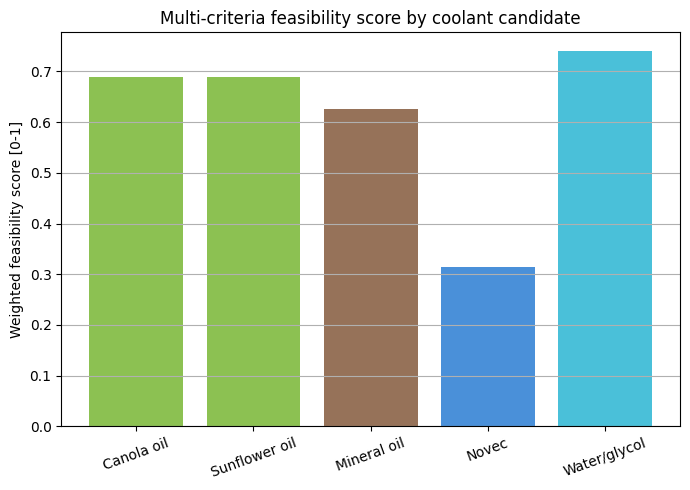

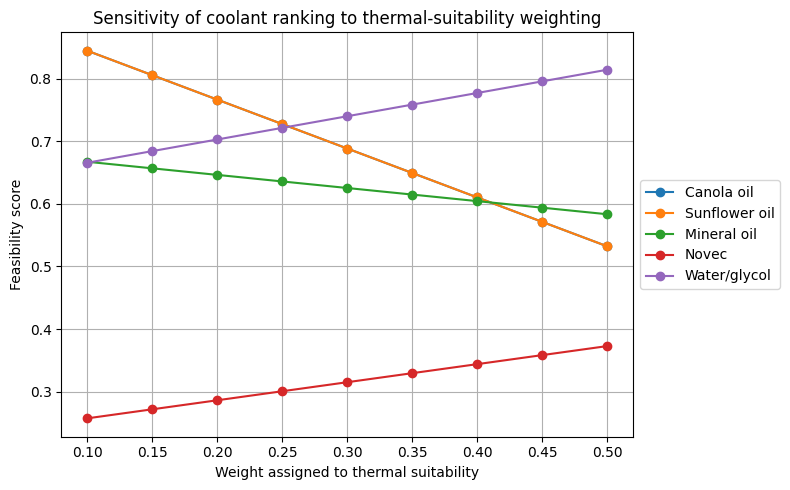

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
coolants = ['Canola oil', 'Sunflower oil', 'Mineral oil', 'Novec', 'Water/glycol']
n = len(coolants)
# ---- Raw property inputs (cited above) ----
k_thermal      = np.array([0.17, 0.17, 0.13, 0.065, 0.60])   # W/m.K
cost_usd_L     = np.array([2.0,  2.0,  5.5,  75,    1.0])     # USD/L
viscosity_rel  = np.array([3.0,  3.0,  1.0,  0.5,   0.3])     # relative to mineral oil (lower = better)
biodegradable  = np.array([1,    1,    0,    0,     0.5])     # 1=yes, 0=no, 0.5=neutral/not applicable
accessibility  = np.array([0.9,  0.9,  0.6,  0.2,   0.7])     # analyst-assigned, 1=simple local supply chain
infra_complexity = np.array([0.2, 0.2, 0.3, 0.3, 0.9])         # 0=simple single loop, 1=complex multi-subsystem
norm_k    = k_thermal / k_thermal.max()
norm_cost = 1 - (cost_usd_L - cost_usd_L.min()) / (cost_usd_L.max() - cost_usd_L.min())
norm_visc = 1 - (viscosity_rel - viscosity_rel.min()) / (viscosity_rel.max() - viscosity_rel.min())
norm_bio  = biodegradable
norm_acc  = accessibility
norm_infra = 1 - infra_complexity
thermal_suitability = 0.5 * norm_k + 0.5 * norm_visc
sustainability = 0.5 * norm_bio + 0.5 * norm_acc
w_thermal = 0.30
w_cost    = 0.30
w_access  = 0.20
w_sustain = 0.20

score = (w_thermal * thermal_suitability + w_cost * norm_cost
         + w_access * norm_infra + w_sustain * sustainability)
results = pd.DataFrame({
    'Coolant': coolants,
    'k_W_mK': k_thermal,
    'Cost_USD_L': cost_usd_L,
    'RelViscosity': viscosity_rel,
    'ThermalSuitability': thermal_suitability,
    'CostScore': norm_cost,
    'Sustainability': sustainability,
    'FeasibilityScore': score
})
print(results.to_string(index=False))
results.to_csv('feasibility_scores.csv', index=False)
print("\nSaved: feasibility_scores.csv")
plt.figure(figsize=(7, 5))
plt.bar(coolants, score, color=['#8CC152','#8CC152','#967259','#4A90D9','#4AC0D9'])
plt.xticks(rotation=20)
plt.ylabel('Weighted feasibility score [0-1]')
plt.title('Multi-criteria feasibility score by coolant candidate')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
w_thermal_range = np.arange(0.1, 0.51, 0.05)
score_matrix = np.zeros((len(w_thermal_range), n))
for i, wt in enumerate(w_thermal_range):
    remaining = 1 - wt
    wc = remaining * (0.30 / 0.70)
    wa = remaining * (0.20 / 0.70)
    ws = remaining * (0.20 / 0.70)
    score_matrix[i, :] = (wt * thermal_suitability + wc * norm_cost
                           + wa * norm_infra + ws * sustainability)
plt.figure(figsize=(8, 5))
for j in range(n):
    plt.plot(w_thermal_range, score_matrix[:, j], '-o', linewidth=1.5, label=coolants[j])
plt.xlabel('Weight assigned to thermal suitability')
plt.ylabel('Feasibility score')
plt.title('Sensitivity of coolant ranking to thermal-suitability weighting')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()